In [1]:
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

X,y = datasets.make_moons(n_samples=500, noise=0.06, random_state=170)
#X,y = datasets.make_circles(n_samples=500, noise=0.08, random_state=10)
custom_colors = ["#4374B3","#FF0B04"]


In [2]:
clf1 = KNeighborsClassifier(n_neighbors=7,metric='l2').fit(X,y)
clf2 =LogisticRegression().fit(X,y)


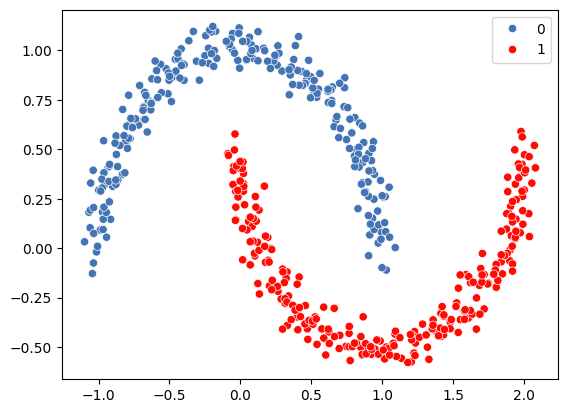

In [3]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y,palette=custom_colors)
plt.show()

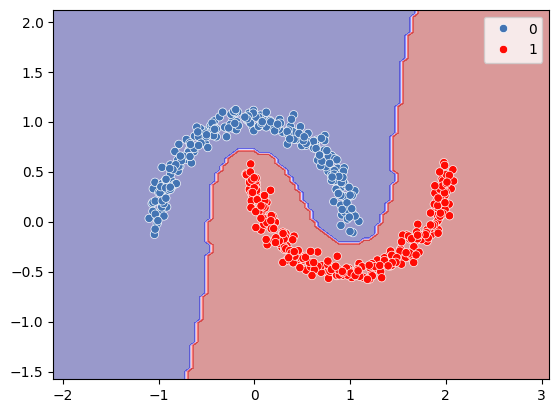

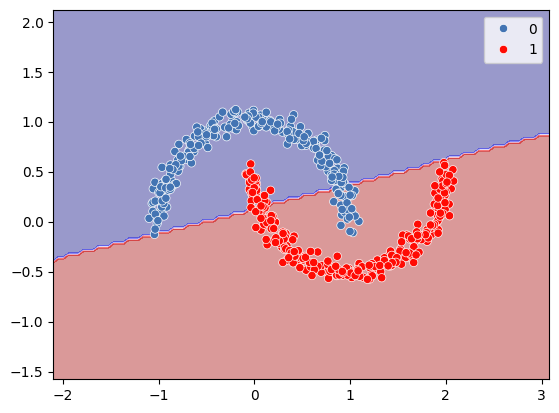

In [9]:

DecisionBoundaryDisplay.from_estimator(
        clf1, X, alpha=0.4, response_method="predict",cmap='seismic'
    )
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y,palette=custom_colors)
plt.show()
DecisionBoundaryDisplay.from_estimator(
        clf2, X, alpha=0.4, response_method="predict",cmap='seismic'
    )
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y,palette=custom_colors)
plt.show()


## Lets look at what happens when we add random features.

NN Dim=0


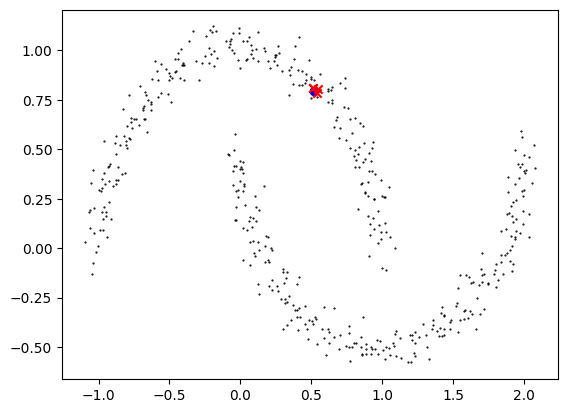

K-NN Prediction


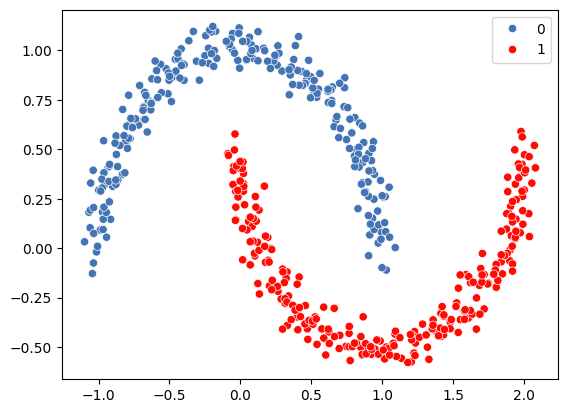

NN Dim=10


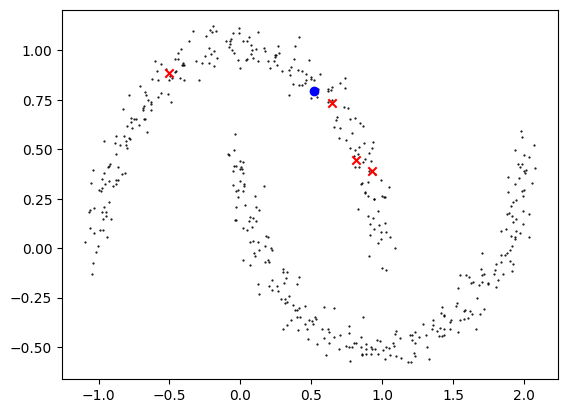

K-NN Prediction


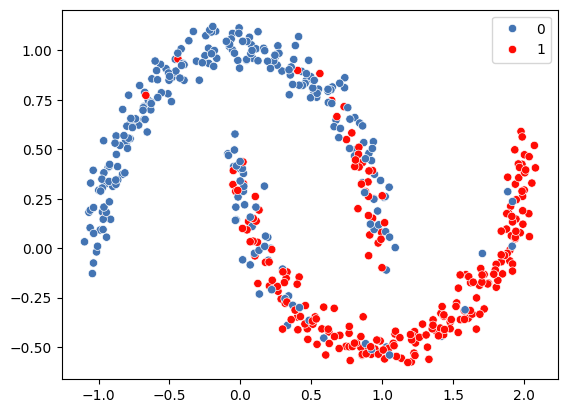

NN Dim=20


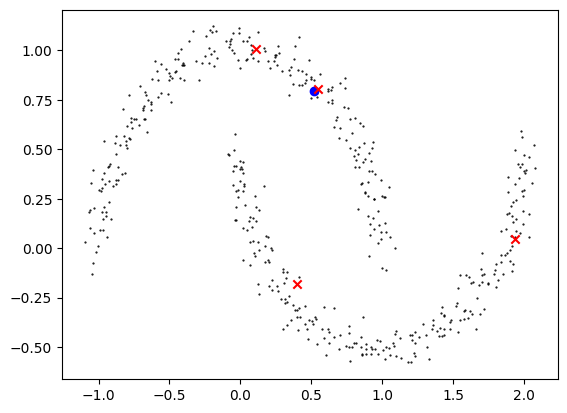

K-NN Prediction


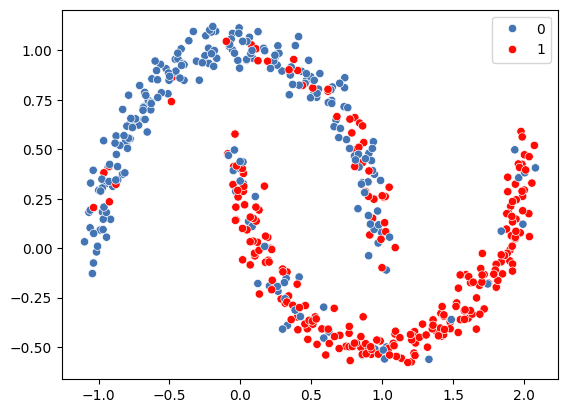

In [16]:
import numpy as np

k=8
for d in range(0,30,10):
    xp=np.concatenate([X, np.random.normal(size=(X.shape[0],d))],axis=-1 )
    nn=np.argsort(np.linalg.norm((xp[1:,:]-xp[0:1,:]),axis=1))[0:4]+1
    print(f"NN Dim={d}")
    clf = KNeighborsClassifier(n_neighbors=7,metric='l2').fit(xp,y)
    yp=clf.predict(xp)
    
    plt.scatter([X[0,0]],[X[0,1]],color='blue')
    plt.scatter([X[nn,0]],[X[nn,1]],color='red',marker='x')

    plt.scatter(X[:,0],X[:,1],color='black',zorder=-1,s=.3)

    plt.show()
    print(f"K-NN Prediction")

    sns.scatterplot(x=X[:,0],y=X[:,1],hue=yp,palette=custom_colors)
    plt.show()
    